# Time Series Analysis

## Importing Libararies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the dataset

In [2]:
df = pd.read_csv("/content/drive/MyDrive/NBICT LAB PDSML-B-8/12. Time Series Analysis/time_series_data.csv")

In [3]:
df.head()

,year,yield_kg_ha,avg_temp_c,annual_rainfall_mm
0,1981,1937.5,25.759616,1506.65
1,1982,1997.9,25.864082,1401.22
2,1983,2205.6,26.407151,997.86
3,1984,2134.6,25.774781,1459.14
4,1985,2148.5,26.358247,1120.34


## Visualizating the primary time series

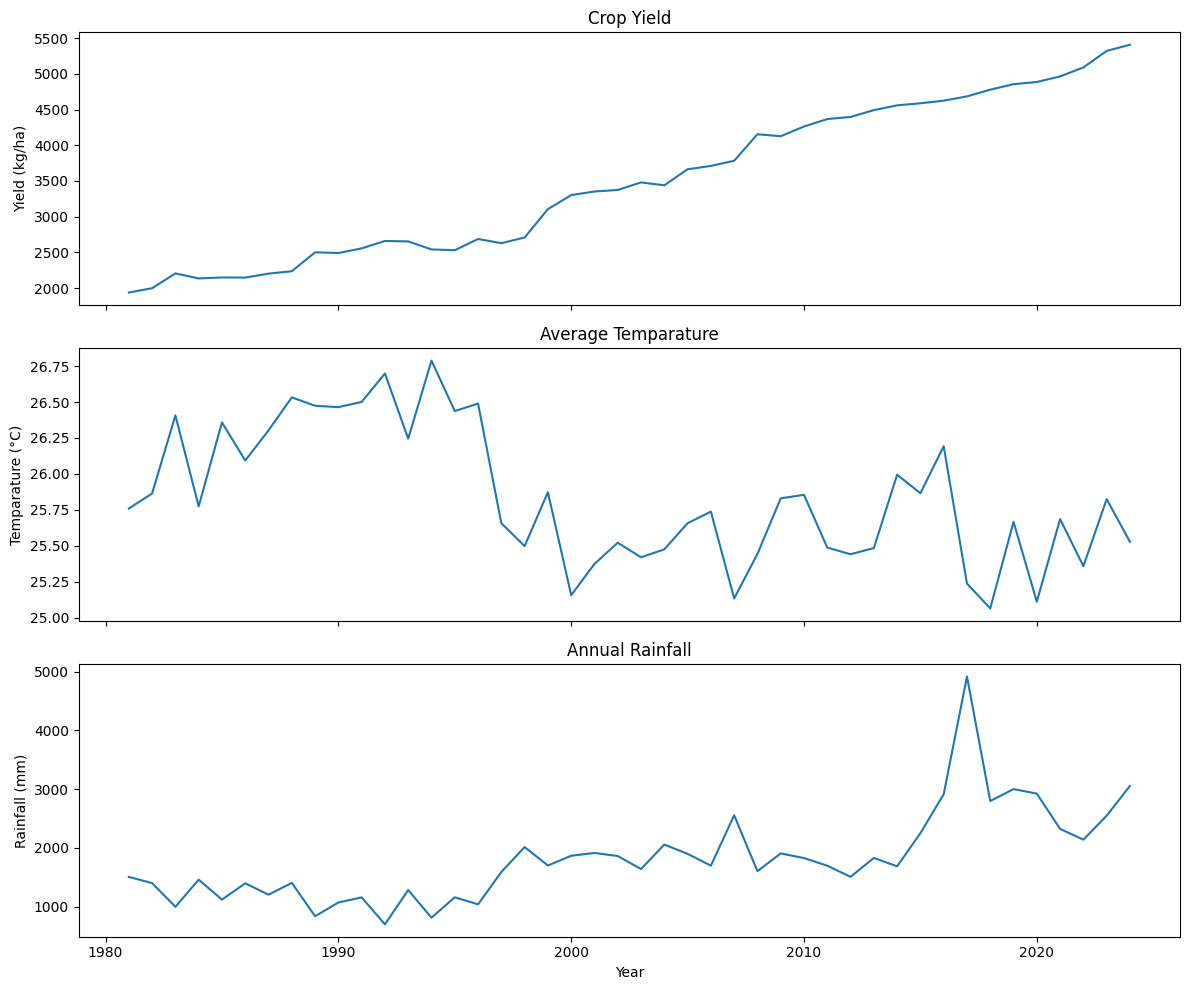

In [4]:
fig, axes = plt.subplots(
    3, 1,
    figsize=(12,10),
    sharex=True
)
axes[0].plot(df['year'], df['yield_kg_ha'])
axes[0].set_ylabel('Yield (kg/ha)')
axes[0].set_title('Crop Yield')


axes[1].plot(df['year'], df['avg_temp_c'])
axes[1].set_ylabel('Temparature (°C)')
axes[1].set_title('Average Temparature')


axes[2].plot(df['year'], df['annual_rainfall_mm'])
axes[2].set_ylabel('Rainfall (mm)')
axes[2].set_title('Annual Rainfall')

plt.xlabel('Year')
plt.tight_layout()
plt.show()

## Adding an explicit time trend

In [5]:
df["time"] = np.arange(len(df))
df.head()

,year,yield_kg_ha,avg_temp_c,annual_rainfall_mm,time
0,1981,1937.5,25.759616,1506.65,0
1,1982,1997.9,25.864082,1401.22,1
2,1983,2205.6,26.407151,997.86,2
3,1984,2134.6,25.774781,1459.14,3
4,1985,2148.5,26.358247,1120.34,4


## Creating the first difference series

In [6]:
diff_df = (
    df.set_index("year")[
        [
        'yield_kg_ha',
        'avg_temp_c',
        'annual_rainfall_mm'
        ]
    ]
    .diff()
    .dropna()
)
diff_df.head()

,yield_kg_ha,avg_temp_c,annual_rainfall_mm
year,,,
1982,60.4,0.104466,-105.43
1983,207.7,0.543068,-403.36
1984,-71.0,-0.632369,461.28
1985,13.9,0.583465,-338.80
1986,-1.9,-0.264849,277.68


In [7]:
diff_df.columns = [
    'yield_change',
    'temp_change',
    'rainfall_change'
]
diff_df.head()

,yield_change,temp_change,rainfall_change
year,,,
1982,60.4,0.104466,-105.43
1983,207.7,0.543068,-403.36
1984,-71.0,-0.632369,461.28
1985,13.9,0.583465,-338.80
1986,-1.9,-0.264849,277.68


In [8]:
# When temparature or rainfall changes relative to her previous year, does crop yeild also tend to change?
diff_df.corr()

,yield_change,temp_change,rainfall_change
yield_change,1.000000,0.208653,-0.328651
temp_change,0.208653,1.000000,-0.438779
rainfall_change,-0.328651,-0.438779,1.000000


## Ploting Changes

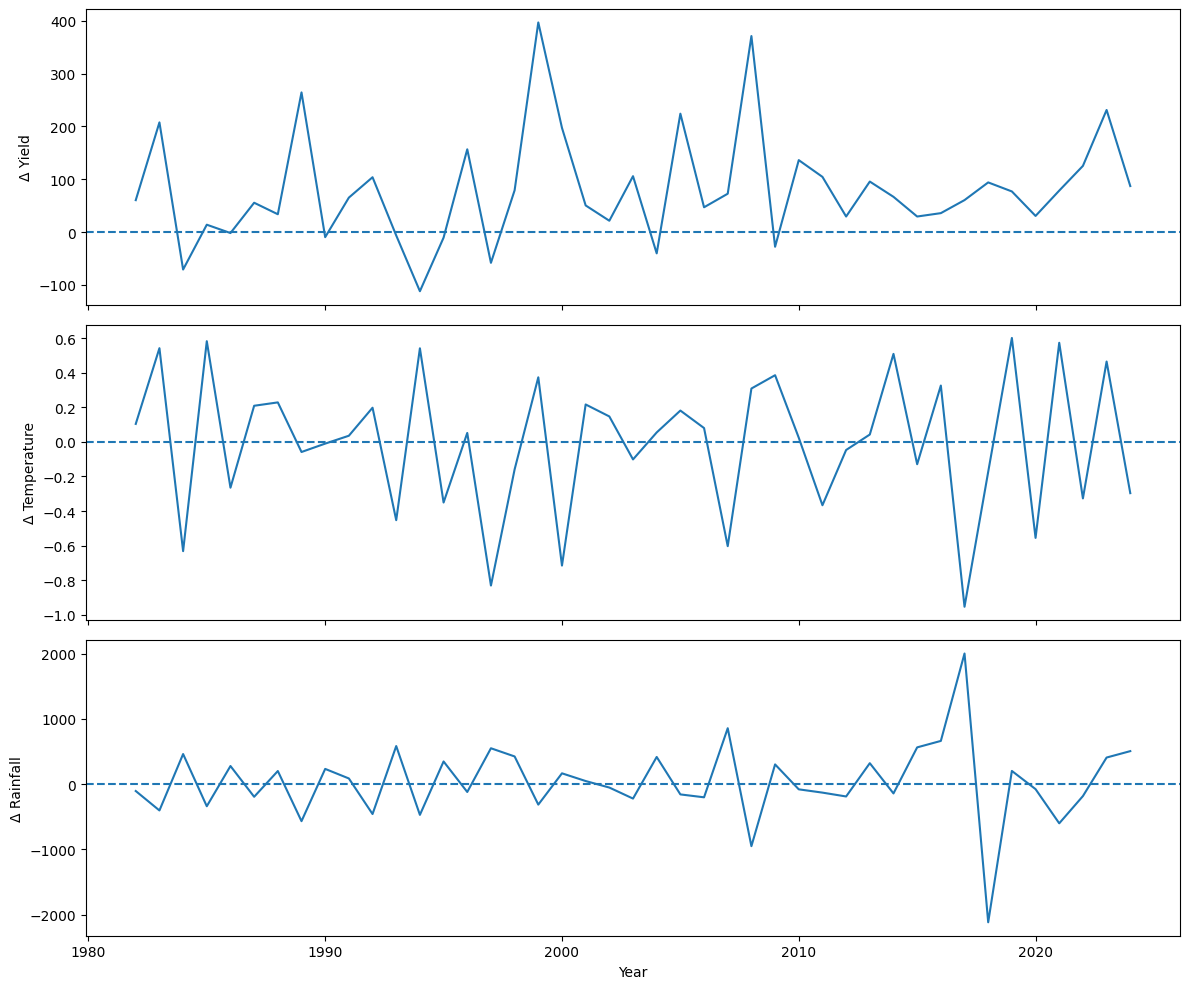

In [9]:
fig, axes = plt.subplots(
    3, 1,
    figsize=(12,10),
    sharex=True
    )

axes[0].plot(diff_df.index, diff_df["yield_change"])
axes[0].axhline(0, linestyle="--")
axes[0].set_ylabel("Δ Yield")

axes[1].plot(diff_df.index, diff_df["temp_change"])
axes[1].axhline(0, linestyle="--")
axes[1].set_ylabel("Δ Temperature")

axes[2].plot(diff_df.index, diff_df["rainfall_change"])
axes[2].axhline(0, linestyle="--")
axes[2].set_ylabel("Δ Rainfall")
axes[2].set_xlabel("Year")

plt.tight_layout()
plt.show()

## Stationarity

When p-value is less than the 0.05 then it is stationary

In [10]:
# Augmented Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller

adfuller_yield = adfuller(df["yield_kg_ha"])
adfuller_temp = adfuller(df["avg_temp_c"])
adfuller_rainfall = adfuller(df["annual_rainfall_mm"])

#p-value
print(f"Yield: {adfuller_yield[1]}")
print(f"Temparature: {adfuller_temp[1]}")
print(f"Rainfall: {adfuller_rainfall[1]}")

Yield: 0.9865755801670226
Temparature: 0.40046249742569406
Rainfall: 0.5306951103213311


In [11]:
# testing change
adfuller_yield = adfuller(diff_df["yield_change"])
adfuller_temp = adfuller(diff_df["temp_change"])
adfuller_rainfall = adfuller(diff_df["rainfall_change"])

# P-value
print(f"Yield: {adfuller_yield[1]}")
print(f"Temparature: {adfuller_temp[1]}")
print(f"Rainfall: {adfuller_rainfall[1]}")

Yield: 2.3033110113847025e-09
Temparature: 3.8658739819060185e-19
Rainfall: 2.373710095651791e-16


## Autocorelation: Is crop yield this year related to crop yield last year?

when the point in the outside of the blue shade then it is said that the corelation is signmificant.

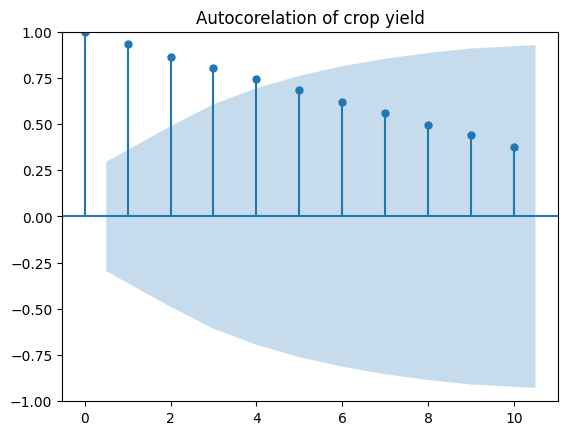

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df["yield_kg_ha"], lags=10)
plt.title('Autocorelation of crop yield')
plt.show()

## Looking at climate relationships visually

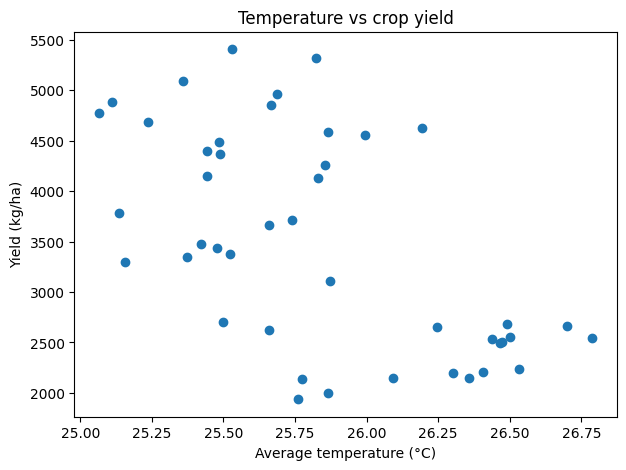

In [15]:
# Temperature vs crop yield
plt.figure(figsize=(7, 5))

plt.scatter(
    df["avg_temp_c"],
    df["yield_kg_ha"]
)

plt.xlabel("Average temperature (°C)")
plt.ylabel("Yield (kg/ha)")
plt.title("Temperature vs crop yield")

plt.show()

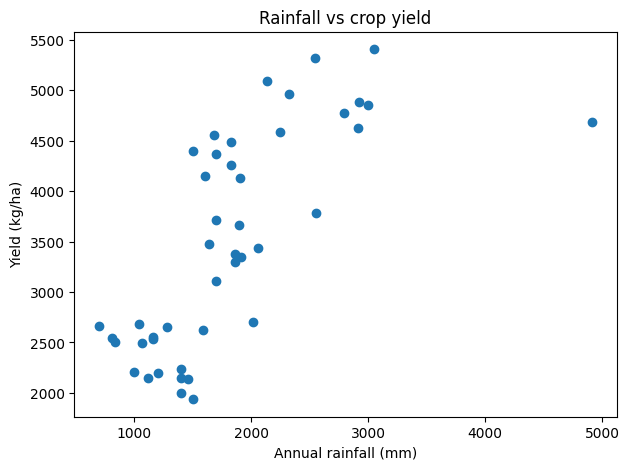

In [16]:
# Rainfall vs crop yield
plt.figure(figsize=(7, 5))

plt.scatter(
    df["annual_rainfall_mm"],
    df["yield_kg_ha"]
)

plt.xlabel("Annual rainfall (mm)")
plt.ylabel("Yield (kg/ha)")
plt.title("Rainfall vs crop yield")

plt.show()

## Better: plot year-to-year changes

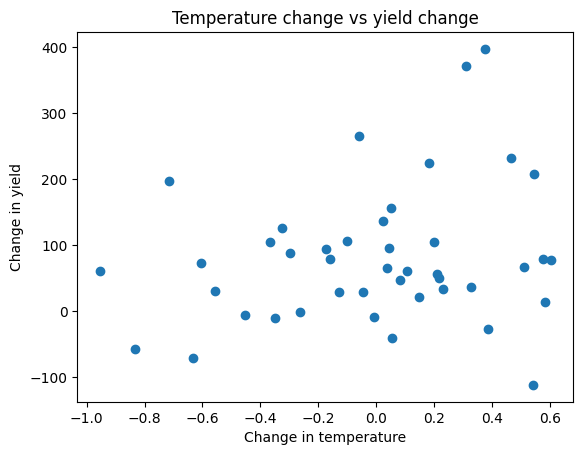

In [17]:
# Temperature change vs yield change
plt.scatter(
    diff_df["temp_change"],
    diff_df["yield_change"]
)

plt.xlabel("Change in temperature")
plt.ylabel("Change in yield")
plt.title("Temperature change vs yield change")

plt.show()

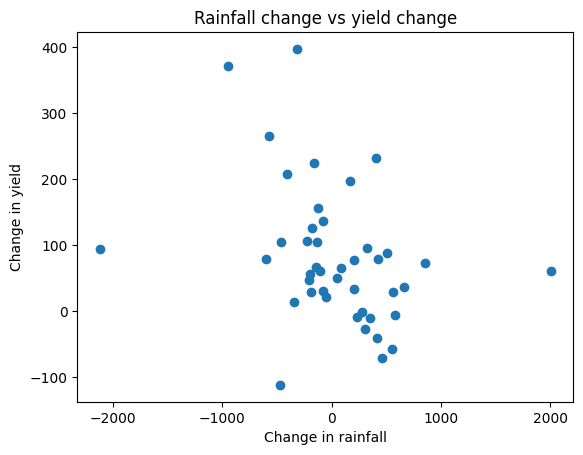

In [18]:
# Rainfall change vs yield change
plt.scatter(
    diff_df["rainfall_change"],
    diff_df["yield_change"]
)

plt.xlabel("Change in rainfall")
plt.ylabel("Change in yield")
plt.title("Rainfall change vs yield change")

plt.show()

## Time series regression SARIMAX

When autocorelation happen then we used to do this.

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [14]:
sarimax_model = SARIMAX(
    endog = df['yield_kg_ha'],
    exog = df[['avg_temp_c', 'annual_rainfall_mm']],
    order = (1,1,0), # (p,d,q) = (1, 1, 0), these as Auto Regressive order, differencing order, and Moving Avarage order respectively
    trend = 'ct' # c = constant, t = linear time trend, ct = both constant and linear trend
)

sarimax_result = sarimax_model.fit()

print(sarimax_result.summary())

                               SARIMAX Results                                
Dep. Variable:            yield_kg_ha   No. Observations:                   44
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -257.483
Date:                Mon, 24 Aug 2026   AIC                            526.965
Time:                        15:42:56   BIC                            537.532
Sample:                             0   HQIC                           530.862
                                 - 44                                         
Covariance Type:                  opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
intercept             54.6307     36.807      1.484      0.138     -17.510     126.772
drift                  1.3328      1.500      0.888      0.374      -1.608       4.274
avg_temp_c          

In [19]:
sarimax_model = SARIMAX(
    endog = df['yield_kg_ha'],
    exog = df[['avg_temp_c', 'annual_rainfall_mm']],
    order = (1,0,0), # (p,d,q) = (1, 1, 0), these as Auto Regressive order, differencing order, and Moving Avarage order respectively
    trend = 'ct' # c = constant, t = linear time trend, ct = both constant and linear trend
)

sarimax_result = sarimax_model.fit()

print(sarimax_result.summary())

                               SARIMAX Results                                
Dep. Variable:            yield_kg_ha   No. Observations:                   44
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -273.036
Date:                Mon, 24 Aug 2026   AIC                            558.071
Time:                        16:09:30   BIC                            568.777
Sample:                             0   HQIC                           562.041
                                 - 44                                         
Covariance Type:                  opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
intercept           -469.0092    681.085     -0.689      0.491   -1803.910     865.892
drift                 12.3194     12.146      1.014      0.310     -11.487      36.126
avg_temp_c          

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
sarimax_model = SARIMAX(
    endog = df['yield_kg_ha'],
    exog = df[['avg_temp_c', 'annual_rainfall_mm']],
    order = (0,1,0), # (p,d,q) = (1, 1, 0), these as Auto Regressive order, differencing order, and Moving Avarage order respectively
    trend = 'ct' # c = constant, t = linear time trend, ct = both constant and linear trend
)

sarimax_result = sarimax_model.fit()

print(sarimax_result.summary())

                               SARIMAX Results                                
Dep. Variable:            yield_kg_ha   No. Observations:                   44
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -257.482
Date:                Mon, 24 Aug 2026   AIC                            524.964
Time:                        16:16:45   BIC                            533.770
Sample:                             0   HQIC                           528.211
                                 - 44                                         
Covariance Type:                  opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
intercept             52.6440     34.703      1.517      0.129     -15.372     120.660
drift                  1.3708      1.454      0.943      0.346      -1.479       4.221
avg_temp_c          